# Financial Sales Analysis

## Objective
The objective of this project is to analyze financial sales data to identify sales trends, revenue distribution, product performance, and key business insights using Python.

### Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- OpenPyXL
- Jupyter Notebook

## 1. Import Libraries
- import pandas
- import numpy
- import matplotlib.pyplot

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns




## 2. Load Dataset

In [2]:
df = pd.read_excel("../data/raw/sample data (1).xlsx")

In [3]:
df.columns = df.columns.str.strip()

## 3. Data Understanding

In [4]:
df.head()

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Month Name,Year
0,Government,Germany,Carretera,NaN,1513.0,3,350,529550.0,0.0,529550.0,393380.0,136170.0,2014-12-01,12,December,2014
1,Government,Germany,Paseo,NaN,1006.0,10,350,352100.0,0.0,352100.0,261560.0,90540.0,2014-06-01,6,June,2014
2,Government,Canada,Paseo,NaN,1725.0,10,350,603750.0,0.0,603750.0,448500.0,155250.0,2013-11-01,11,November,2013
3,Government,Germany,Paseo,NaN,1513.0,10,350,529550.0,0.0,529550.0,393380.0,136170.0,2014-12-01,12,December,2014
4,Government,Germany,Velo,NaN,1006.0,120,350,352100.0,0.0,352100.0,261560.0,90540.0,2014-06-01,6,June,2014


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Segment              700 non-null    str           
 1   Country              700 non-null    str           
 2   Product              700 non-null    str           
 3   Discount Band        647 non-null    str           
 4   Units Sold           700 non-null    float64       
 5   Manufacturing Price  700 non-null    int64         
 6   Sale Price           700 non-null    int64         
 7   Gross Sales          700 non-null    float64       
 8   Discounts            700 non-null    float64       
 9   Sales                700 non-null    float64       
 10  COGS                 700 non-null    float64       
 11  Profit               700 non-null    float64       
 12  Date                 700 non-null    datetime64[us]
 13  Month Number         700 non-null    int64    

In [6]:
df.shape

(700, 16)

In [7]:
df.columns

Index(['Segment', 'Country', 'Product', 'Discount Band', 'Units Sold',
       'Manufacturing Price', 'Sale Price', 'Gross Sales', 'Discounts',
       'Sales', 'COGS', 'Profit', 'Date', 'Month Number', 'Month Name',
       'Year'],
      dtype='str')

In [8]:
df.describe()

,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Year
count,700.000000,700.000000,700.000000,7.000000e+02,700.000000,7.000000e+02,700.000000,700.000000,700,700.000000,700.000000
mean,1608.294286,96.477143,118.428571,1.827594e+05,13150.354629,1.696091e+05,145475.211429,24133.860371,2014-04-28 21:36:00,7.900000,2013.750000
min,200.000000,3.000000,7.000000,1.799000e+03,0.000000,1.655080e+03,918.000000,-40617.500000,2013-09-01 00:00:00,1.000000,2013.000000
25%,905.000000,5.000000,12.000000,1.739175e+04,800.320000,1.592800e+04,7490.000000,2805.960000,2013-12-24 06:00:00,5.750000,2013.750000
50%,1542.500000,10.000000,20.000000,3.798000e+04,2585.250000,3.554020e+04,22506.250000,9242.200000,2014-05-16 12:00:00,9.000000,2014.000000
75%,2229.125000,250.000000,300.000000,2.790250e+05,15956.343750,2.610775e+05,245607.500000,22662.000000,2014-09-08 12:00:00,10.250000,2014.000000
max,4492.500000,260.000000,350.000000,1.207500e+06,149677.500000,1.159200e+06,950625.000000,262200.000000,2014-12-01 00:00:00,12.000000,2014.000000
std,867.427859,108.602612,136.775515,2.542623e+05,22962.928775,2.367263e+05,203865.506118,42760.626563,NaN,3.377321,0.433322


## 4. Data Cleaning

In [9]:
df.isnull().sum()

Segment                 0
Country                 0
Product                 0
Discount Band          53
Units Sold              0
Manufacturing Price     0
Sale Price              0
Gross Sales             0
Discounts               0
Sales                   0
COGS                    0
Profit                  0
Date                    0
Month Number            0
Month Name              0
Year                    0
dtype: int64

In [10]:
df["Discount Band"].value_counts(dropna=False)

Discount Band
High      245
Medium    242
Low       160
NaN        53
Name: count, dtype: int64

In [11]:
df["Discount Band"] = df["Discount Band"].fillna("No Discount")

In [12]:
df[df["Discount Band"].isnull()]

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Month Name,Year


In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df = df.drop_duplicates()

In [15]:
df.shape

(700, 16)

In [16]:
df["Discount Band"].value_counts(dropna=False)

Discount Band
High           245
Medium         242
Low            160
No Discount     53
Name: count, dtype: int64

In [17]:
df.isnull().sum()

Segment                0
Country                0
Product                0
Discount Band          0
Units Sold             0
Manufacturing Price    0
Sale Price             0
Gross Sales            0
Discounts              0
Sales                  0
COGS                   0
Profit                 0
Date                   0
Month Number           0
Month Name             0
Year                   0
dtype: int64

## Exploratory Data Analysis (EDA)

### EDA Question 1: Which Country Has the Highest Sales?

In [18]:
country_sales = df.groupby("Country")["Sales"].sum().sort_values(ascending=False)

country_sales

Country
United States of America    2.502983e+07
Canada                      2.488765e+07
France                      2.435417e+07
Germany                     2.350534e+07
Mexico                      2.094935e+07
Name: Sales, dtype: float64

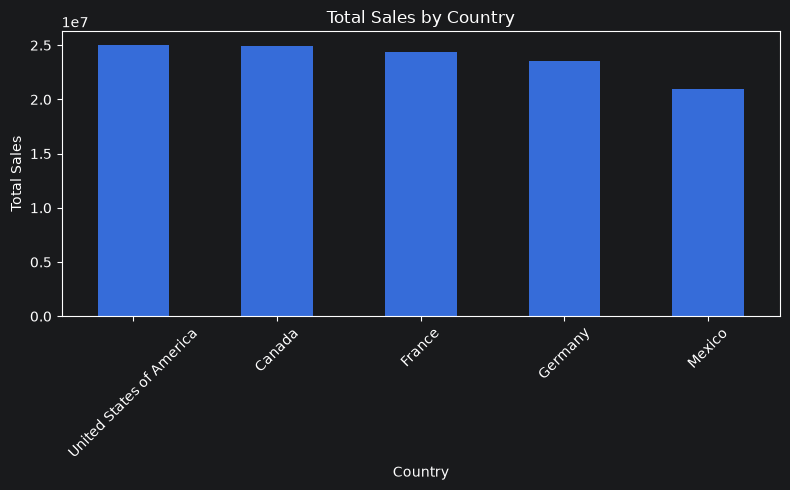

In [19]:
plt.figure(figsize=(8,5))

country_sales.plot(kind="bar")

plt.title("Total Sales by Country")
plt.xlabel("Country")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

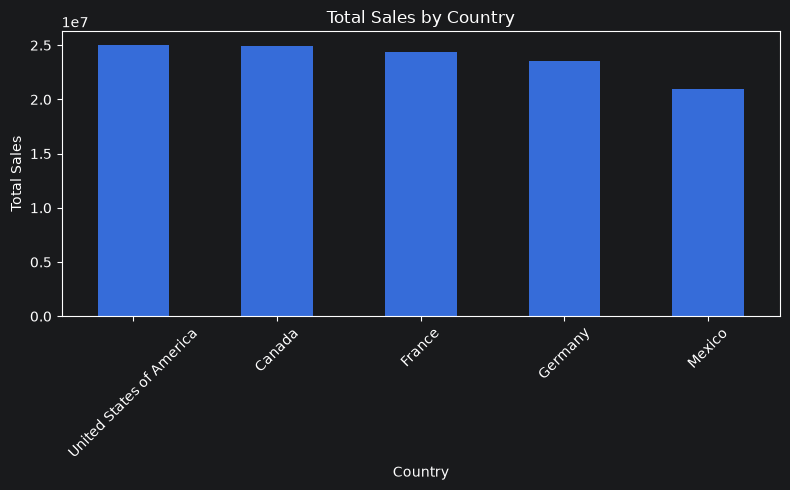

In [20]:
plt.figure(figsize=(8,5))

country_sales.plot(kind="bar")

plt.title("Total Sales by Country")
plt.xlabel("Country")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../outputs/charts/country_sales.png")

plt.show()

## Insight

- The country with the highest total sales is 2.502983e+07.
- This country contributes the largest share of revenue.
- The company should continue focusing on this market while identifying opportunities to improve sales in lower-performing countries.

### EDA Question 2: Which Product Generates the Highest Profit?

In [21]:
product_profit = df.groupby("Product")["Profit"].sum().sort_values(ascending=False)
product_profit

Product
Paseo        4797437.950
VTT          3034608.020
Amarilla     2814104.060
Velo         2305992.465
Montana      2114754.880
Carretera    1826804.885
Name: Profit, dtype: float64

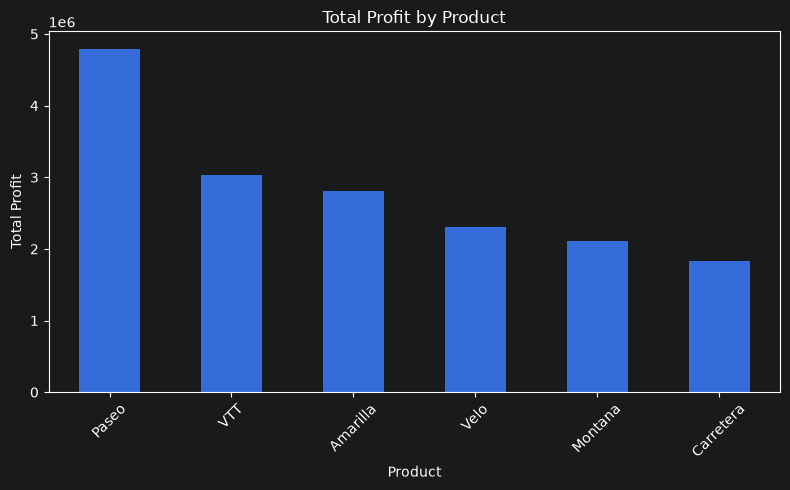

In [22]:
plt.figure(figsize=(8,5))

product_profit.plot(kind="bar")

plt.title("Total Profit by Product")
plt.xlabel("Product")
plt.ylabel("Total Profit")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

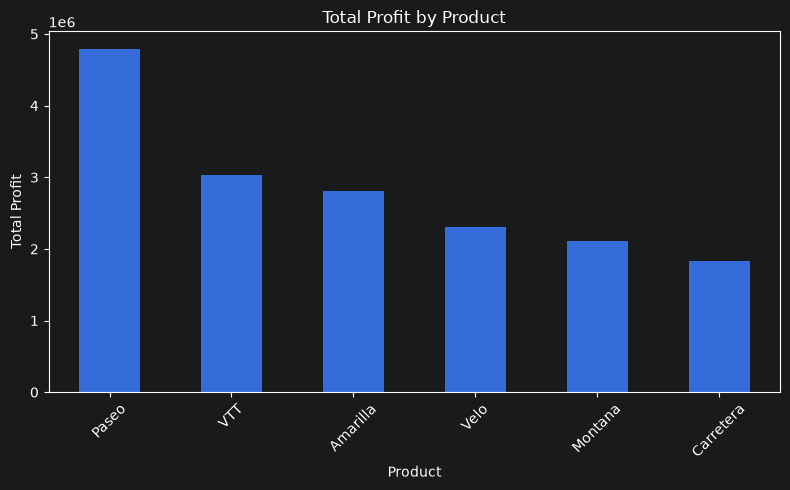

In [23]:
plt.figure(figsize=(8,5))

product_profit.plot(kind="bar")

plt.title("Total Profit by Product")
plt.xlabel("Product")
plt.ylabel("Total Profit")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../outputs/charts/product_profit.png")

plt.show()

## Insight

- The product with the highest total profit is 4797437.950.
- This product contributes the largest share of overall profit.
- The company should continue investing in this product while analyzing why lower-performing products generate less profit.

### EDA Question 3: Which Customer Segment Generates the Highest Sales?

In [24]:
segment_sales = df.groupby("Segment")["Sales"].sum().sort_values(ascending=False)

segment_sales

Segment
Government          5.250426e+07
Small Business      4.242792e+07
Enterprise          1.961169e+07
Midmarket           2.381883e+06
Channel Partners    1.800594e+06
Name: Sales, dtype: float64

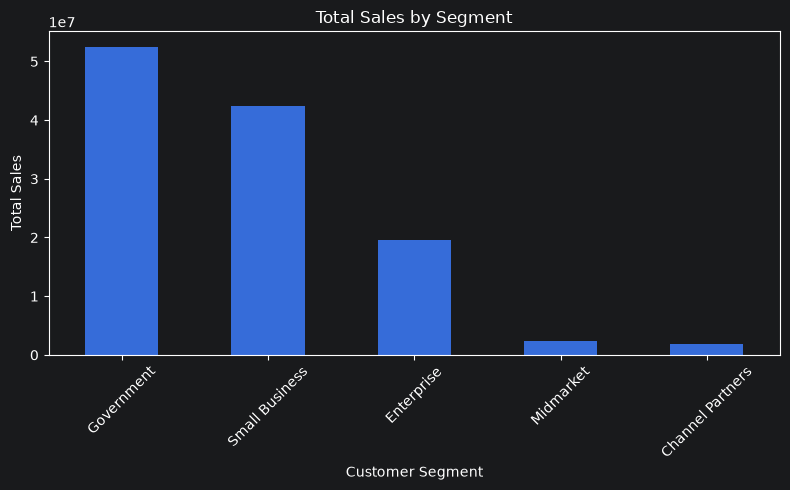

In [25]:
plt.figure(figsize=(8,5))

segment_sales.plot(kind="bar")

plt.title("Total Sales by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

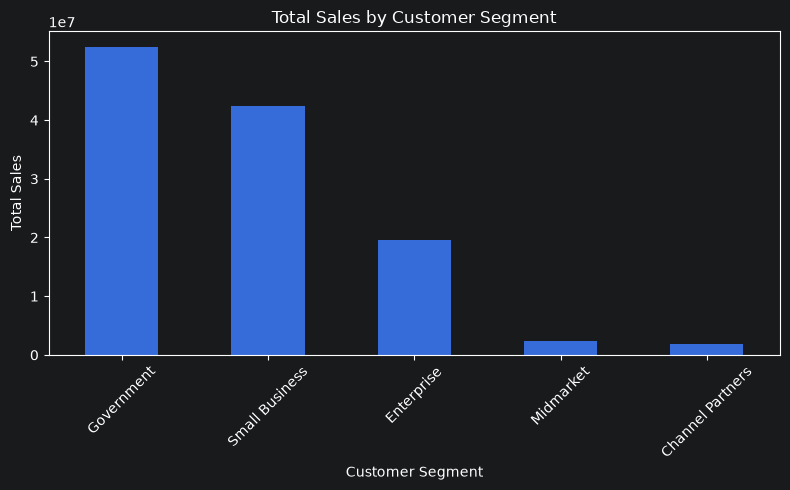

In [26]:
plt.figure(figsize=(8,5))

segment_sales.plot(kind="bar")

plt.title("Total Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../outputs/charts/segment_sales.png")

plt.show()

### Business Insight

- The Government segment generates the highest total sales.
- This segment is the company's largest revenue contributor.
- The company should strengthen customer relationships and marketing efforts for this segment while exploring ways to increase sales in lower-performing segments.

### EDA Question 4: Which Year Had the Highest Sales?

In [27]:
year_sales = df.groupby("Year")["Sales"].sum().sort_values(ascending=False)

year_sales

Year
2014    92311094.75
2013    26415255.51
Name: Sales, dtype: float64

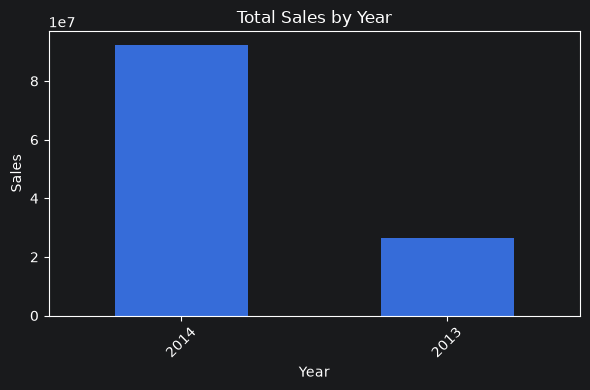

In [45]:
plt.figure(figsize=(6,4))

year_sales.plot(kind="bar")

plt.title("Total Sales by Year")
plt.xlabel("Year")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

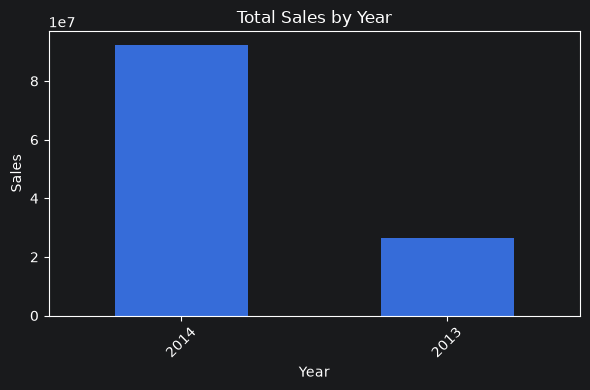

In [29]:
plt.figure(figsize=(6,4))

year_sales.plot(kind="bar")

plt.title("Total Sales by Year")
plt.xlabel("Year")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../outputs/charts/Year_sales.png")

plt.show()

### insight

   - The year 2014 recorded the highest total sales with approximately 92311094.75.
      - indicating stronger business performance compared to 2013.
   - This suggests that sales increased over time and the company experienced better revenue generation during that year.

### EDA Question 5: Which Month Generates the Highest Sales?

In [30]:
month_sales = df.groupby("Month Name")["Sales"].sum().sort_values(ascending=False)

month_sales

Month Name
October      21671431.02
December     17367228.98
November     12651417.50
September    10882697.27
June          9518893.82
July          8102920.18
February      7297531.39
April         6964775.07
January       6607761.68
May           6210211.06
August        5864622.42
March         5586859.87
Name: Sales, dtype: float64

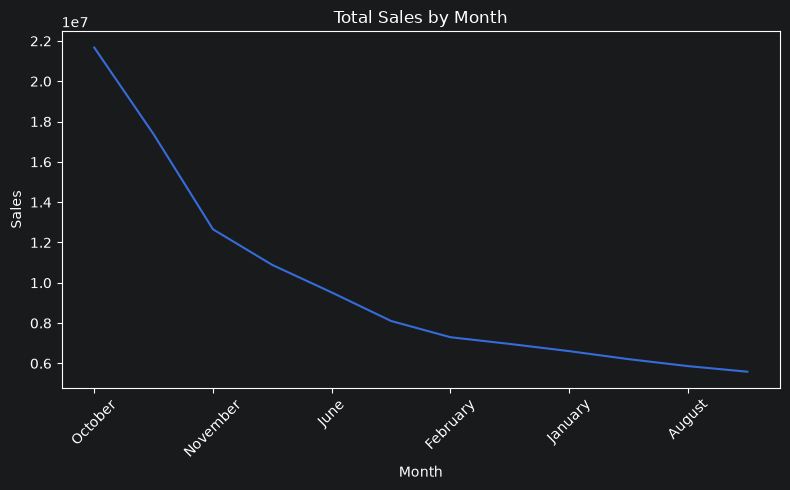

In [31]:
plt.figure(figsize=(8,5))

month_sales.plot(kind="line")

plt.title("Total Sales by Month")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

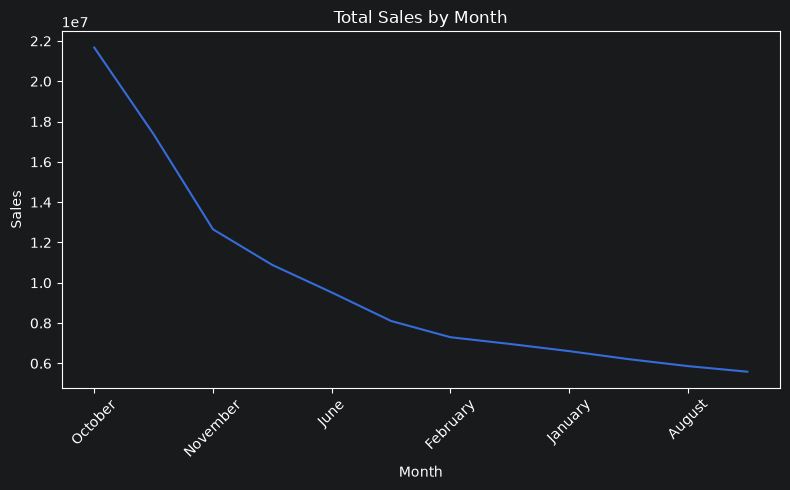

In [43]:
plt.figure(figsize=(8,5))

month_sales.plot(kind="line")

plt.title("Total Sales by Month")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../outputs/charts/Month_sales.png")

plt.show()

### insight

   -  October generated highest sales among all months with approximately 21671431.02.
      - while march recorded the lowest sales approximately 5586859.87.
   - This suggests seasonal variations in customer demand, which can help the company plan inventory, marketing campaigns, and promotional offers more effectively.

### EDA Question 6: Which Discount Band Generates the Highest Sales?

In [33]:
discount_sales = df.groupby("Discount Band")["Sales"].sum().sort_values(ascending=False)

discount_sales

Discount Band
Medium         3.878043e+07
High           3.737249e+07
Low            3.462978e+07
No Discount    7.943654e+06
Name: Sales, dtype: float64

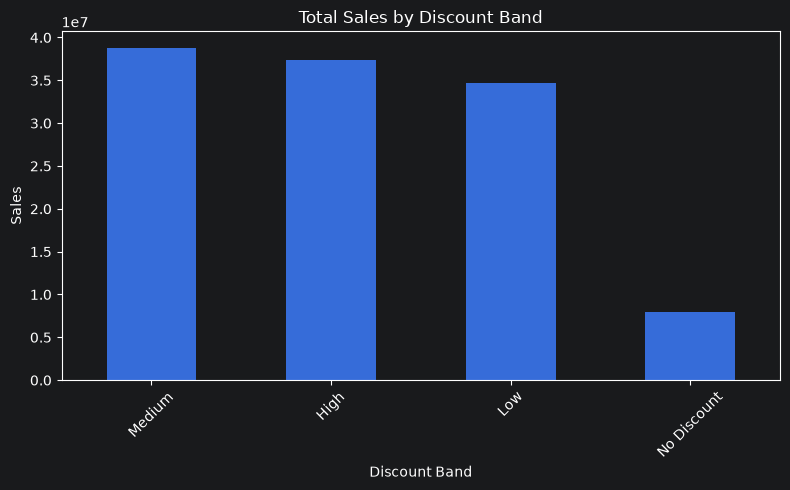

In [34]:
plt.figure(figsize=(8,5))

discount_sales.plot(kind="bar")

plt.title("Total Sales by Discount Band")
plt.xlabel("Discount Band")
plt.ylabel("Sales")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../outputs/charts/Discount_sales.png", dpi=300)

plt.show()


### insight

   - The medium discount band generated the highest sales approximately 3.878043e+07.
   - This indicates that this level of discount was most effective in driving customer purchases.
   - The company can analyze whether this discount strategy also maintains healthy profit margins before expanding it.


### EDA Question 7: Which Country Generates the Highest Profit?

In [35]:
country_profit = df.groupby("Country")["Profit"].sum().sort_values(ascending=False)

country_profit

Country
France                      3781020.780
Germany                     3680388.820
Canada                      3529228.885
United States of America    2995540.665
Mexico                      2907523.110
Name: Profit, dtype: float64

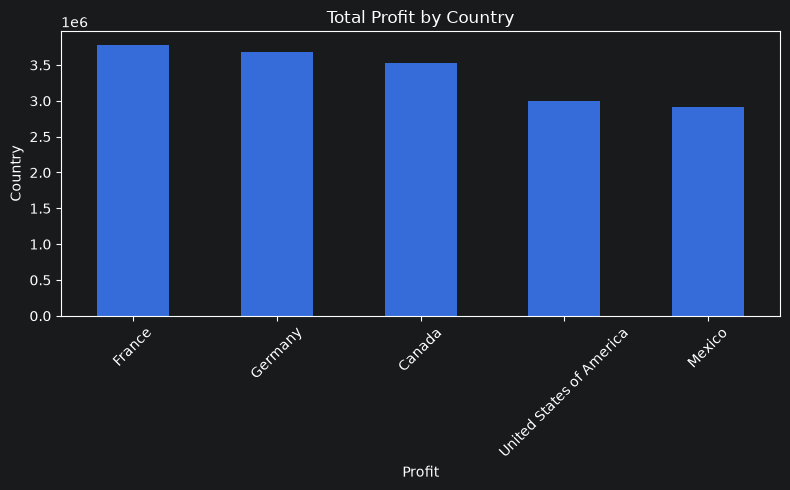

In [36]:
plt.figure(figsize=(8,5))

country_profit.plot(kind="bar")

plt.title("Total Profit by Country")
plt.xlabel("Profit")
plt.ylabel("Country")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../outputs/charts/country_profit.png", dpi=300)

plt.show()

### insights

   - France generated the highest total profit, making it the company's most profitable market.
      - It generated the total profit value approximately 3781020.780.
   - This suggests strong market performance and efficient sales operations in that country.
   - The company should continue investing in this market while identifying opportunities to improve profitability in lower-performing countries.

# Regression Model: Predicting Sales

In this section, we build a Linear Regression model to predict Sales based on product and financial features.

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [38]:
X = df[
    [
        "Units Sold",
        "Manufacturing Price",
        "Sale Price"
    ]
]

y = df["Sales"]

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R² Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R² Score: 0.762339997458229
MAE: 83644.48058984755
MSE: 13162352455.768625


## Regression Model Results

A Linear Regression model was trained using the following features:

- Units Sold
- Manufacturing Price
- Sale Price

### Model Performance

- R² Score: 0.7623
- Mean Absolute Error (MAE): 83,644.48
- Mean Squared Error (MSE): 13,162,352,455.77

### Interpretation

The model explains approximately 76% of the variation in Sales, indicating a reasonably strong relationship between the selected features and the target variable. While the predictions are not perfect, the model captures the overall sales trend and can be useful for forecasting.

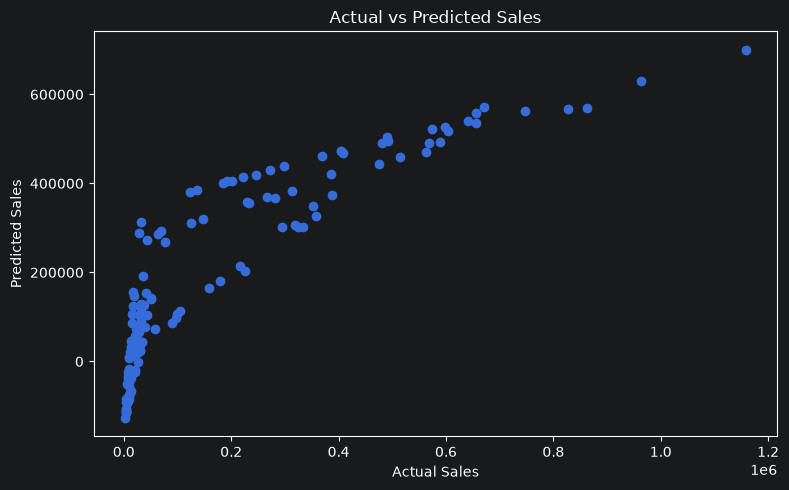

In [40]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.title("Actual vs Predicted Sales")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.tight_layout()
plt.savefig("../outputs/charts/actual_vs_predicted_sales.png", dpi=300)

plt.show()

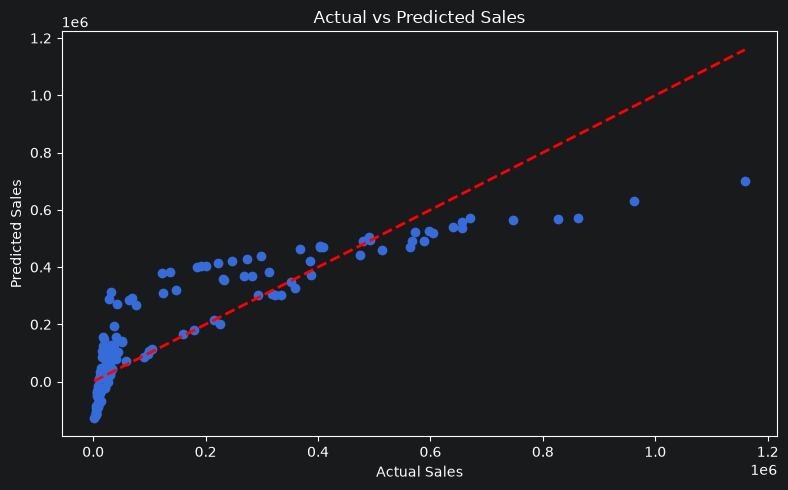

In [41]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--",
    linewidth=2
)

plt.title("Actual vs Predicted Sales")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.tight_layout()
plt.savefig("../outputs/charts/actual_vs_predicted_sales.png", dpi=300)

plt.show()

In [42]:
df.to_csv("../data/processed//financial_sales_cleaned.csv", index=False)

##  SQL Analysis

### SQL Question 1: Which Country Generates the Highest Sales?

Insight:

- Germany generated the highest total sales among all countries.
- This indicates Germany is the strongest-performing market.
- The company should continue investing in this region while exploring growth opportunities in lower-performing countries.

### SQL Question 2: Which Product Generates the Highest Profit?

Insight:

- The product with the highest total profit contributes significantly to the company's overall profitability.
- High-profit products should receive greater marketing focus and inventory priority.
- Lower-profit products should be reviewed for pricing or cost optimization.

### SQL Question 3: Which Customer Segment Generates the Highest Sales?

Insight:

- The Government segment generated the highest total sales.
- This customer segment is the primary revenue driver.
- The business should strengthen relationships and marketing strategies for Government customers.

### SQL Question 4: What is the Total Sales for Each Product?

Insight:

- Sales are distributed unevenly across products.
- A few products contribute the majority of revenue.
- High-selling products should be kept well-stocked and promoted further.

### SQL Question 5: Which Country Earned the Highest Profit?

Insight:

- Profit varies across countries despite similar sales volumes.
- Countries with high profit margins should receive additional business investment.
- Low-profit countries may require pricing or operational improvements.

### SQL Question 6: Which Month Recorded the Highest Sales?

Insight:

- Sales peak during specific months, indicating seasonal demand.
- Marketing campaigns should be planned before these peak periods.
- Inventory should also be increased during high-demand months.

### SQL Question 7: What is the Average Sales by Customer Segment?

Insight:

- Average sales differ across customer segments.
- High-value customer segments generate greater revenue per transaction.
- These customers should receive personalized offers and premium services.

### SQL Question 8: Which Discount Band Generates the Highest Sales?

Insight:

- Products with High Discount generated the highest sales volume.
- Discounts successfully increase revenue.
- However, profitability should also be monitored to avoid excessive discounting.

### SQL Question 9: Which Product Has the Highest Number of Units Sold?

Insight:

- The top-selling product has the highest customer demand.
- Maintaining sufficient inventory for this product is essential.
- The product can also be highlighted in promotional campaigns.

### SQL Question 10: Top 5 Highest Profit Transactions

Insight:

- A small number of transactions contribute a large portion of total profit.
- Understanding these high-value transactions can help identify successful pricing and sales strategies.
- Similar opportunities should be targeted in future sales campaigns.

##  Final Business Recommendations
- Government customers are the company's largest revenue source.
- Germany is the highest-performing country in terms of sales.
- High Discount products generate strong sales but should be monitored for profitability.
- Focus on promoting top-selling and high-profit products.
- Prepare inventory before peak sales months to meet customer demand.
- Use targeted marketing for high-value customer segments.
- The regression model achieved an R² Score of approximately 0.76, indicating good predictive performance for estimating sales.